In [173]:
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

#read in all words
words = open('names.txt', 'r').read().splitlines()

block_size = 4
def build_dataset(words):
    X,Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print("".join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append
    X=torch.tensor(X)
    Y=torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

# create lookup maps
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
X,Y = build_dataset(words)

# Create test,dev and training datasets
# training split, dev/validation split, test split
# 80%,10%,10%
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([228146, 4]) torch.Size([228146])
torch.Size([182625, 4]) torch.Size([182625])
torch.Size([22655, 4]) torch.Size([22655])
torch.Size([22866, 4]) torch.Size([22866])


In [50]:
C = torch.randn((27,2)).float()
C[torch.tensor([4,5,6])]
emb = C[X]
emb.shape
W1 = torch.randn((6, 100))
b1 = torch.randn(100)
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
h.shape

W2 = torch.randn((100,27))
b2 = torch.randn(27)

logits = h @ W2 + b2
logits.shape

counts = logits.exp()
prob = counts/counts.sum(1, keepdims=True)
print(prob.shape)
print(prob[0].sum())
loss = -prob[torch.arange(32), Y].log().mean()
loss

torch.Size([32, 100])

In [179]:
### refactor
g = torch.Generator().manual_seed(2147483647)
emb_width = 30
emb_len = emb_width * block_size
C = torch.randn((27,emb_width), generator=g)
W1 = torch.randn((emb_len,200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200,27), generator=g)
b2 = torch.randn((27), generator=g)
# lre = torch.linspace(-3,0,1000)
# lrs = 10**lre
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

print(Xtr.shape, Ytr.shape) # dataset shape
print(f"num parameters: {sum(p.nelement() for p in parameters)}") # number of parameters in total

torch.Size([182625, 4]) torch.Size([182625])
num parameters: 30437


In [180]:
lri = []
lossi = []
stepi = []

In [188]:

for i in range(60000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,emb_len) @ W1 + b1)
    logits = h @ W2 + b2 #(32,27)
    loss = F.cross_entropy(logits, Ytr[ix])

    #backwad passs
    for p in parameters:
        p.grad = None
    loss.backward()

    # lr = lrs[i]
    lr = 0.1 if i < 40000 else 0.01
    
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
print(loss.item())


1.8485376834869385


In [185]:
# plt.plot(stepi, lossi)

In [189]:
emb = C[Xtr] # (32,3,2)
h = torch.tanh(emb.view(-1,emb_len) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0943, grad_fn=<NllLossBackward0>)

In [190]:
emb = C[Xdev] # (32,3,2)
h = torch.tanh(emb.view(-1,emb_len) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1711, grad_fn=<NllLossBackward0>)

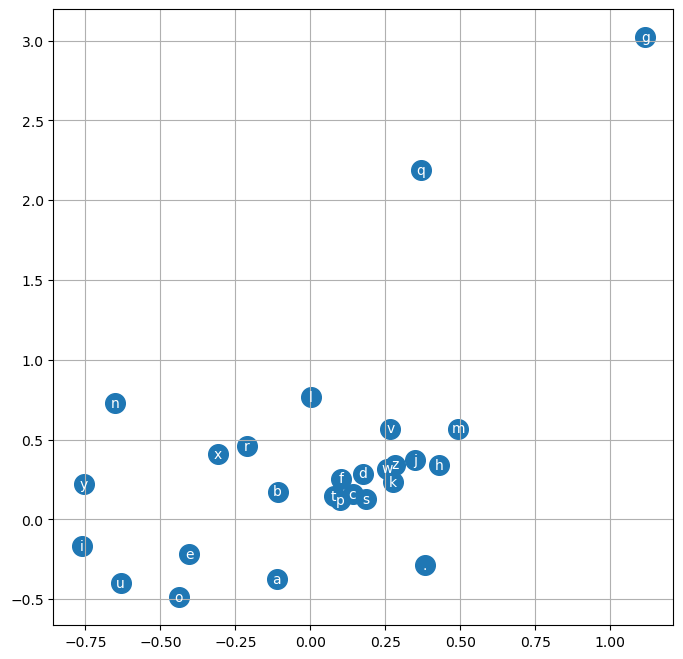

In [67]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid("minor")

In [193]:
# sample from the model
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all '...'
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))
    
    

cexbe.
moalyus.
ilai.
tyha.
kolimitta.
nrlandi.
kaida.
samiyah.
javeri.
miai.
milie.
cavo.
kerted.
jenne.
kamside.
enkamiray.
folse.
hicin.
broahlyn.
kashi.
